# DCT data inspection

Small notebook for first-look inspection of an older DCT scan. Sections mirror the dataset table in `src/Planning`:

1. Raw data — HDF5, `uint16`, `(3600, 2048, 2048)`, optical-distortion corrected
2. Preprocessed data — HDF5, `float32`, moving median + direct-beam handling
3. Segmentation data — HDF5, `uint8`, 3D binary mask
4. Diffraction blobs — HDF5, `float32`, 3D blobs + metadata
5. Preprocessed LoG — TAR of TIFs (partial)

**Set `SCAN_DIR` in the setup cell to point at one scan, then run top-to-bottom.** Each section runs a `peek` first that prints the file's structure — adjust the dataset key names to match what's actually there.

In [2]:
from pathlib import Path
import io, tarfile
import h5py
import hdf5plugin  # noqa: F401 — registers Blosc/Bitshuffle/LZ4 used by ESRF
import numpy as np
import matplotlib.pyplot as plt

In [3]:
DATA_ROOT = Path(r"../../data_esrf/")

# Registry of all scans. `main` = primary frame stack (3D, uint16 or float32).
# Optional: `pre` (precomputed float32 preprocessed), `log_tar` (LoG-TIF tar).
# Every folder has segvol.h5 / dataset "segvol" — assumed by default.
DATASETS = {
  "Al":              {"main": "_iris_iris_500_cont.h5",
                      "pre":  "full.h5"},
  "Al_big_grains":   {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
  "Al_deformed_LoG": {"main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5",
                      "log_tar": "A2050_as_annealed_DT_W370_0p12_strain_dct3.tar"},
  "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
  "Cu":              {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
  "IN718_twins":     {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
  "Iron":            {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
  "Iron_deformed":   {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
  "Ti7Al":           {"main": "sam_23_dct4_sam_23_dct.h5"},
}

# === SELECT SCAN ===  change this one line, re-run setup, then run sections below
MATERIAL = "Al"

entry     = DATASETS[MATERIAL]
SCAN_DIR  = DATA_ROOT / MATERIAL
raw_path  = SCAN_DIR / entry["main"]
RAW_KEY   = entry.get("main_key", "instrument/detector_0/data")
PRE_KEY   = entry.get("pre_key",  "image/data")
SEG_KEY   = entry.get("seg_key",  "segvol")

N_HALF          = 10
FRIEDEL_OFFSET  = 1800       # frames = 180° at 0.1°/frame
START           = 1200       # side A start; side B = START + FRIEDEL_OFFSET

def peek_h5(path):
  with h5py.File(path, "r") as f:
      print(f"== {path.name} ==")
      def visitor(name, obj):
          if isinstance(obj, h5py.Dataset):
              print(f"DATASET  {name:40s} shape={obj.shape} dtype={obj.dtype}")
          elif isinstance(obj, h5py.Group):
              print(f"GROUP    {name}")
      f.visititems(visitor)

def load_batch_pair(ds, start=START, n=N_HALF, offset=FRIEDEL_OFFSET):
  """Read n frames at `start` and n frames at `start + offset` (180° around).
  Returns (start_a, batch_a, start_b, batch_b)."""
  a = ds[start : min(ds.shape[0], start + n)]
  sb = start + offset
  b = ds[sb : min(ds.shape[0], sb + n)]
  return start, a, sb, b

def show_montage_pair(batch_a, start_a, batch_b, start_b,
                      cmap="gray", suptitle=None, frame_size=6):
  """Display two batches side-by-side as two columns of full-resolution frames."""
  n = max(len(batch_a), len(batch_b))
  fig, axes = plt.subplots(n, 2, figsize=(2 * frame_size, frame_size * n))
  if n == 1:
      axes = axes.reshape(1, 2)
  for col, (batch, s0, side) in enumerate([
      (batch_a, start_a, "+ω"),
      (batch_b, start_b, "+ω+180°"),]):
      for i in range(n):
          ax = axes[i, col]
          if i < len(batch):
              ax.imshow(batch[i], cmap=cmap)
              ax.set_title(f"{side}   ω={s0 + i}", fontsize=11)
          ax.axis("off")
  if suptitle:
      fig.suptitle(suptitle, fontsize=13)
  fig.tight_layout()

print(f"Available scans: {list(DATASETS)}")
print(f"\nSelected: {MATERIAL}  →  {SCAN_DIR}")
print(f"  main: {entry['main']}")
if "pre" in entry:     print(f"  pre:  {entry['pre']}")
if "log_tar" in entry: print(f"  tar:  {entry['log_tar']}")
print()
print(f"Listing {SCAN_DIR}:")
for p in sorted(SCAN_DIR.glob("*")):
    suffix = "/" if p.is_dir() else ""
    size = "—" if p.is_dir() else f"{p.stat().st_size // 1024**2} MB"
    print(f"  {p.name + suffix:80s}  {size}")


Available scans: ['Al', 'Al_big_grains', 'Al_deformed_LoG', 'Al_small_grains', 'Cu', 'IN718_twins', 'Iron', 'Iron_deformed', 'Ti7Al']

Selected: Al  →  ../../data_esrf/Al
  main: _iris_iris_500_cont.h5
  pre:  full.h5

Listing ../../data_esrf/Al:
  _dark.h5                                                                          7 MB
  _iris_iris_500_cont.h5                                                            9103 MB
  confirmed_spots.h5                                                                0 MB
  full.h5                                                                           25665 MB
  segvol.h5                                                                         176 MB


## 1. Raw data
`uint16`, `(T=3600, H=2048, W=2048)`, optical-distortion corrected.

== _iris_iris_500_cont.h5 ==
GROUP    instrument
GROUP    instrument/detector_0
DATASET  instrument/detector_0/data               shape=(3600, 2048, 2048) dtype=uint16
GROUP    instrument/detector_0/others
DATASET  instrument/detector_0/others/Date        shape=(3600,) dtype=|S11
GROUP    instrument/file
DATASET  instrument/file/scan_header              shape=(3600,) dtype=|S183
GROUP    measurement
GROUP    measurement/image_0
GROUP    measurement/image_0/info
GROUP    measurement/image_0/info/others
DATASET  measurement/image_0/info/others/Date     shape=(3600,) dtype=|S11
DATASET  names                                    shape=(3600,) dtype=object
full shape=(3600, 2048, 2048) dtype=uint16
side A: frames [1200..1209]  |  side B: frames [3000..3009]  (160 MB in RAM)


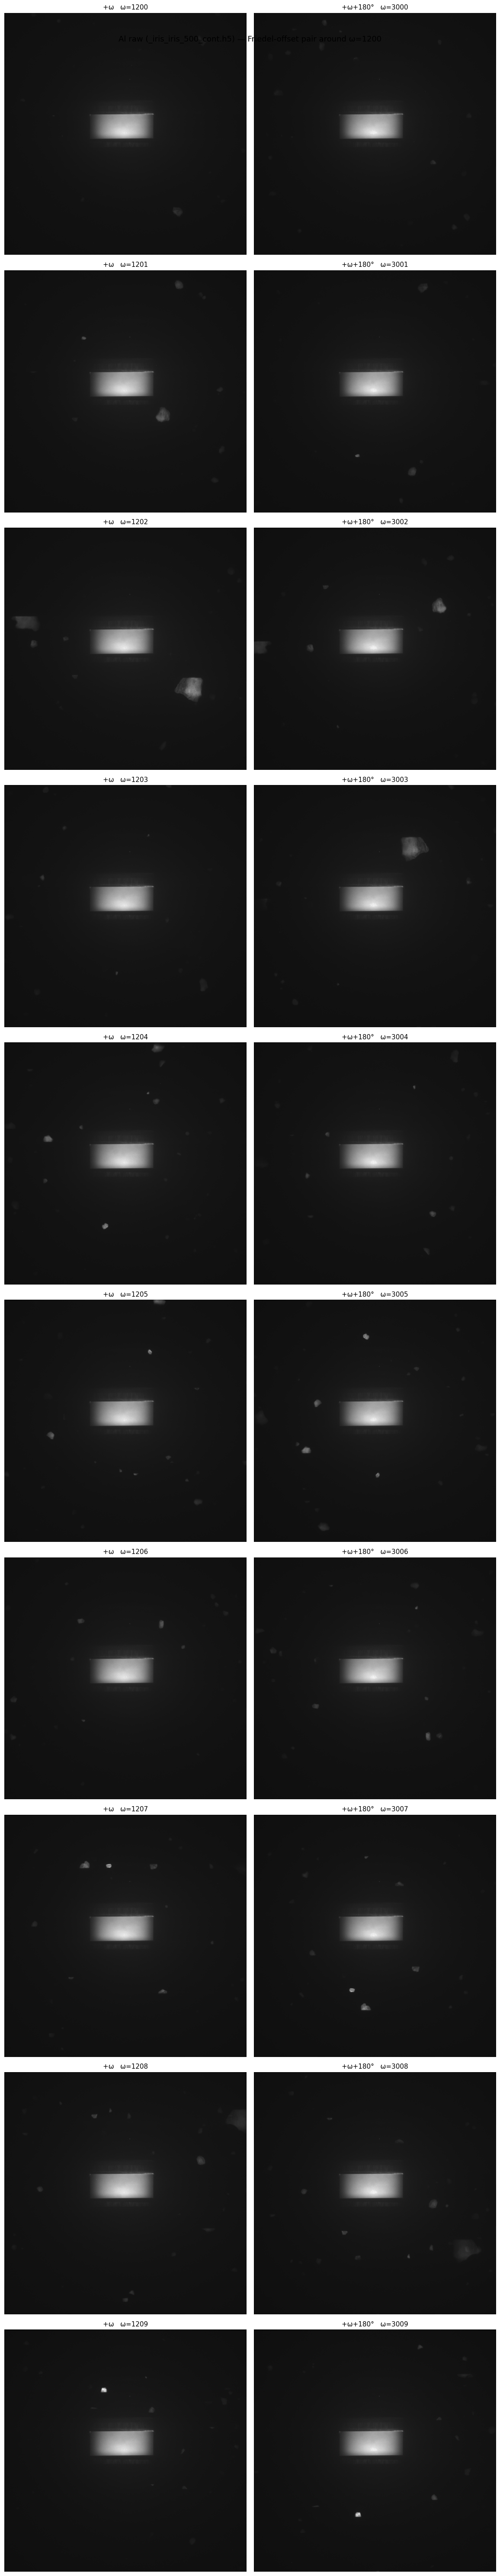

In [4]:
peek_h5(raw_path)

with h5py.File(raw_path, "r") as f:
  raw = f[RAW_KEY]
  print(f"full shape={raw.shape} dtype={raw.dtype}")
  sa, ba, sb, bb = load_batch_pair(raw)
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb,
                  suptitle=f"{MATERIAL} raw ({raw_path.name}) — Friedel-offset pair around ω={sa}")


## 2. Preprocessed data
`float32`, same shape as raw. Moving median + special direct-beam handling applied upstream.

In [ ]:
if "pre" not in entry:
  print(f"No preprocessed file registered for {MATERIAL}. Skipping.")
else:
  pre_path = SCAN_DIR / entry["pre"]
  peek_h5(pre_path)

  with h5py.File(pre_path, "r") as f:
      pre = f[PRE_KEY]
      print(f"full shape={pre.shape} dtype={pre.dtype}")
      sa, ba, sb, bb = load_batch_pair(pre)
      print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
            f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
            f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

  show_montage_pair(ba, sa, bb, sb, cmap="magma",
                    suptitle=f"{MATERIAL} preprocessed ({pre_path.name}) — Friedel-offset pair around ω={sa}")


== full.h5 ==
GROUP    image
DATASET  image/data                               shape=(3672, 2048, 2048) dtype=float32
GROUP    instrument
GROUP    instrument/detector_0
DATASET  instrument/detector_0/data               shape=(3672, 2048, 2048) dtype=float32
GROUP    instrument/detector_0/others
DATASET  instrument/detector_0/others/Date        shape=(3672,) dtype=|S11
GROUP    instrument/file
DATASET  instrument/file/scan_header              shape=(3672,) dtype=|S165
GROUP    measurement
GROUP    measurement/image_0
GROUP    measurement/image_0/info
GROUP    measurement/image_0/info/others
DATASET  measurement/image_0/info/others/Date     shape=(3672,) dtype=|S11
DATASET  names                                    shape=(3672,) dtype=object
full shape=(3672, 2048, 2048) dtype=float32


## 3. Segmentation mask
`uint8`, same shape. Adaptive-threshold 3D binary mask.

In [6]:
seg_path = SCAN_DIR / "segvol.h5"   # labeled segmentation (uint16, label IDs not binary)
peek_h5(seg_path)

with h5py.File(seg_path, "r") as f:
  seg = f[SEG_KEY]
  print(f"full shape={seg.shape} dtype={seg.dtype}")
  sa, ba, sb, bb = load_batch_pair(seg)
  n_labels_a = len(np.unique(ba)) - 1   # exclude background 0
  n_labels_b = len(np.unique(bb)) - 1
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  {n_labels_a} unique label(s)  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  {n_labels_b} unique label(s)  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb, cmap="tab20",
                  suptitle=f"{MATERIAL} segmentation labels — Friedel-offset pair around ω={sa}")


== segvol.h5 ==
DATASET  segvol                                   shape=(3600, 2048, 2048) dtype=uint16
full shape=(3600, 2048, 2048) dtype=uint16


KeyboardInterrupt: 

## 4. Diffraction blobs
`float32`, 3D blobs + per-blob metadata. Exact schema unknown — this cell prints whatever is there.

In [ ]:
blobs_path = SCAN_DIR / "blobs.h5"   # TODO: adjust filename
peek_h5(blobs_path)

with h5py.File(blobs_path, "r") as f:
    for name in f.keys():
        obj = f[name]
        if isinstance(obj, h5py.Dataset):
            print(f"\n{name}: shape={obj.shape} dtype={obj.dtype}")
            if obj.size > 0:
                head = obj[: min(5, obj.shape[0])]
                print(f"  first {len(head)} record(s):\n  {head}")
        elif isinstance(obj, h5py.Group):
            print(f"\n[group] {name}: {list(obj.keys())}")

## 5. Preprocessed LoG TIFs (TAR, partial)
Laplacian-of-Gaussian edge maps as a tarball of TIFs. Only partially complete — some frames may be missing.

3600 .tif files found in img_seg/
proj0000.tif: shape=(2048, 2048), min=0, max=11393
proj1800.tif: shape=(2048, 2048), min=0, max=8935
proj0001.tif: shape=(2048, 2048), min=0, max=6792
proj1801.tif: shape=(2048, 2048), min=0, max=13992
proj0002.tif: shape=(2048, 2048), min=0, max=11223
proj1802.tif: shape=(2048, 2048), min=0, max=20105
proj0003.tif: shape=(2048, 2048), min=0, max=12104
proj1803.tif: shape=(2048, 2048), min=0, max=23259
proj0004.tif: shape=(2048, 2048), min=0, max=9990
proj1804.tif: shape=(2048, 2048), min=0, max=16845
proj0005.tif: shape=(2048, 2048), min=0, max=12117
proj1805.tif: shape=(2048, 2048), min=0, max=14592
proj0006.tif: shape=(2048, 2048), min=0, max=9783
proj1806.tif: shape=(2048, 2048), min=0, max=12177
proj0007.tif: shape=(2048, 2048), min=0, max=7527
proj1807.tif: shape=(2048, 2048), min=0, max=10660
proj0008.tif: shape=(2048, 2048), min=0, max=6556
proj1808.tif: shape=(2048, 2048), min=0, max=10701
proj0009.tif: shape=(2048, 2048), min=0, max=7151
proj

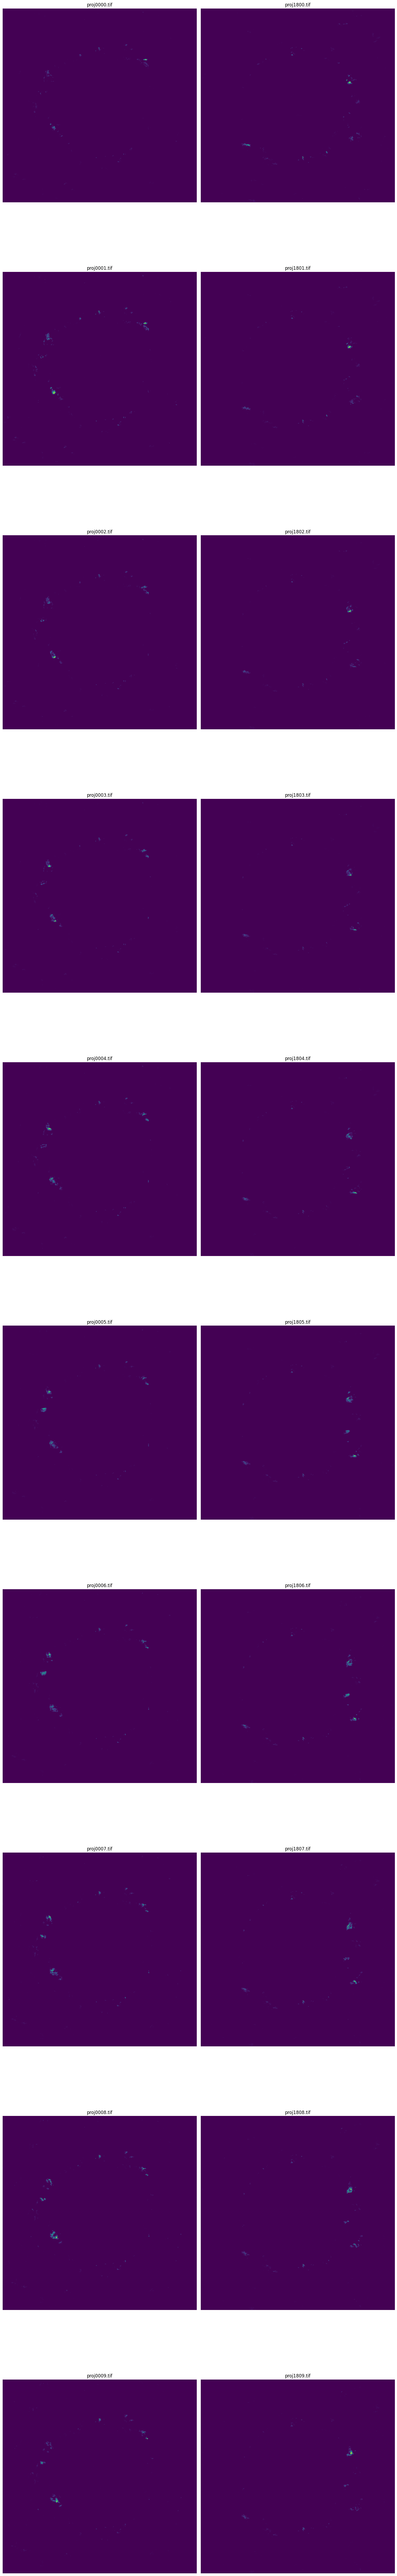

In [21]:
img_seg_path = SCAN_DIR / "im_seg" 

from PIL import Image  # pip install Pillow if missing

# Find all .tif files
tif_files = sorted(img_seg_path.glob("*.tif"))
print(f"{len(tif_files)} .tif files found in img_seg/")

# First 5 and comparison range
first_indices = range(0, 10)        # 0001–0006
compare_indices = range(1800, 1810)  # 0180–0184

fig, axes = plt.subplots(10, 2, figsize=(15, 100))

for row, (i1, i2) in enumerate(zip(first_indices, compare_indices)):
    
    # Build filenames
    p1 = img_seg_path / f"proj{i1:04d}.tif"
    p2 = img_seg_path / f"proj{i2:04d}.tif"

    # Load images
    img1 = np.array(Image.open(p1))
    img2 = np.array(Image.open(p2))

    print(f"{p1.name}: shape={img1.shape}, min={img1.min()}, max={img1.max()}")
    print(f"{p2.name}: shape={img2.shape}, min={img2.min()}, max={img2.max()}")

    # Left column
    axes[row, 0].imshow(img1, cmap="viridis")
    axes[row, 0].set_title(p1.name)
    axes[row, 0].axis("off")

    # Right column (mirrored horizontally)
    axes[row, 1].imshow(np.fliplr(img2), cmap="viridis")
    axes[row, 1].set_title(p2.name)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
img_seg_path = SCAN_DIR / "im_seg"

from PIL import Image  # pip install Pillow if missing

# Find all .tif files
tif_files = sorted(img_seg_path.glob("*.tif"))
print(f"{len(tif_files)} .tif files found in im_seg/")

# Pair the two index ranges and lay them out as two horizontal rows
first_indices = range(1, 50)
compare_indices = range(50, 100)
pairs = list(zip(first_indices, compare_indices))

fig, axes = plt.subplots(2, len(pairs), figsize=(3 * len(pairs), 12))

for col, (i1, i2) in enumerate(pairs):
    p1 = img_seg_path / f"proj{i1:04d}.tif"
    p2 = img_seg_path / f"proj{i2:04d}.tif"

    img1 = np.array(Image.open(p1))
    img2 = np.array(Image.open(p2))

    print(f"{p1.name}: shape={img1.shape}, min={img1.min()}, max={img1.max()}")
    print(f"{p2.name}: shape={img2.shape}, min={img2.min()}, max={img2.max()}")

    # Top row: left column images
    axes[0, col].imshow(img1, cmap="viridis")
    axes[0, col].set_title(p1.name)
    axes[0, col].axis("off")

    # Bottom row: right column images (mirrored horizontally)
    axes[1, col].imshow(np.fliplr(img2), cmap="viridis")
    axes[1, col].set_title(p2.name)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()


---
Once the filenames and HDF5 keys are confirmed for one scan, generalise by looping `(material, scan)` over `DATA_ROOT.glob("*/*")`.